In [2]:
# !pip install xgboost

In [31]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import os, sys
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

#### Data Ingestion

In [4]:
train_transaction=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\ieee-fraud-detection\train_transaction.csv")
train_identity=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\ieee-fraud-detection\train_identity.csv")

In [5]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## **EDA**

In [7]:
print(f"Shape of train_transaction: {train_transaction.shape}")
print(f"Shape of train_identity: {train_identity.shape}")

Shape of train_transaction: (590540, 394)
Shape of train_identity: (144233, 41)


In [8]:
train_transaction_col=train_transaction.columns.tolist()
train_identity_col=train_identity.columns.tolist()

##### Merge both datasets on `TransactionID` columns

In [9]:
df=train_transaction.merge(train_identity, on='TransactionID',how='left')

In [10]:
print("train_transaction shape:", train_transaction.shape)
print("Fraud rate:", df["isFraud"].mean().round(4))

train_transaction shape: (590540, 394)
Fraud rate: 0.035


### Feature Audit & Selection

**The following columns were intentionally excluded, along with the reasons:**

* **TransactionID:** Removed because it is only a unique identifier and does not provide any predictive value for the model.

* **TransactionDT:** Used exclusively for time-based train/test splitting (see Section 4) rather than as a model feature. Including it as a feature could cause the model to learn temporal patterns or the order of transactions, which would not generalize well to future, unseen data.

* **V1–V339:** These are anonymized and transformed features created by **Vesta**, the original data provider. Although their individual business meaning is unknown, they have consistently demonstrated strong predictive performance in public research on this dataset. Therefore, they are retained as **black-box features**, acknowledging that they cannot be interpreted from a business perspective.

* **Categorical Features (e.g., ProductCD, card4, card6, P_emaildomain, R_emaildomain, DeviceType, M1–M9, etc.):** In the initial version of the project, these columns were dropped because only numerical features were considered. In the updated version, they are properly encoded and included in the model, as attributes such as **ProductCD** and **DeviceType** carry meaningful business information (similar to transaction category or device type) and can significantly improve predictive performance.


In [11]:
def audit_columns(df:pd.DataFrame)->pd.DataFrame:
    """
    1.Identifying the data type of each feature.
    2.Measuring the percentage of missing values.
    3.Counting the number of unique values.
    4.Ranking features by missing rate.
    """
    audit=pd.DataFrame({
        "dtype":df.dtypes,
        "missing_rate":df.isnull().mean(),
        "unique_count":df.nunique()
    })
    return audit.sort_values(by="missing_rate",ascending=False)

audit=audit_columns(df)
""" 
Identifying columns with more than 90% missing values
as candidates for removal to improve data quality and reduce 
unnecessary complexity before model training.
"""
high_missing_cols=audit[audit["missing_rate"]>0.9].index.tolist()
high_missing_cols

['id_24',
 'id_25',
 'id_07',
 'id_08',
 'id_21',
 'id_26',
 'id_27',
 'id_23',
 'id_22',
 'dist2',
 'D7',
 'id_18']

In [12]:
audit

,dtype,missing_rate,unique_count
id_24,float64,0.991962,12
id_25,float64,0.991310,341
id_07,float64,0.991271,84
id_08,float64,0.991271,94
id_21,float64,0.991264,490
...,...,...,...
C11,float64,0.000000,1476
C14,float64,0.000000,1108
C13,float64,0.000000,1597
C12,float64,0.000000,1199


In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering domain-specific untuk konteks merchant risk."""
    data = df.copy()
    data["transaction_hour"] = (data["TransactionDT"] / 3600) % 24
    data["log_transaction_amt"] = np.log1p(data["TransactionAmt"])
    data["has_device_info"] = data["DeviceInfo"].notna().astype(int)
    data["email_domain_mismatch"] = (
        data["P_emaildomain"] != data["R_emaildomain"]
    ).astype(int)
    return data

In [14]:
CATEGORICAL_COLS = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
]
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df.columns]

In [15]:
def encode_categoricals(df: pd.DataFrame, cat_cols: list[str]) -> pd.DataFrame:
    """Label-encode kolom kategorikal. XGBoost tidak butuh one-hot, dan
    label encoding cukup untuk tree-based model selama kita sadar hasilnya
    bukan ordinal yang bermakna."""
    data = df.copy()
    for col in cat_cols:
        data[col] = data[col].astype(str).fillna("missing")
        data[col] = LabelEncoder().fit_transform(data[col])
    return data

In [16]:
df_fe = engineer_features(df)
df_fe = encode_categoricals(df_fe, CATEGORICAL_COLS)

In [17]:
drop_cols = ["TransactionID", "isFraud", "TransactionDT"] + [
    c for c in high_missing_cols if c not in CATEGORICAL_COLS
]
feature_cols = [c for c in df_fe.columns if c not in drop_cols]
feature_cols = [c for c in feature_cols if df_fe[c].dtype in [np.float64, np.int64, np.int32]]

X = df_fe[feature_cols].fillna(-999)
y = df_fe["isFraud"]
transaction_dt = df_fe["TransactionDT"]  # disimpan terpisah untuk time-based split

In [18]:
print(f"Number of features used: {len(feature_cols)} (after encoding & missing value filtering)")
print(f"Encoded categorical features: {CATEGORICAL_COLS}")

Number of features used: 409 (after encoding & missing value filtering)
Encoded categorical features: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


## **Train Test Split (time basis)**

### **Why not use a random split?**

Financial transactions follow **temporal patterns**—fraud strategies evolve over time. A random train-test split allows the model to **peek into future transaction patterns** during training, leading to overly optimistic validation scores that do not reflect how the model will perform in a real-world deployment. In production, the model must predict fraud on **new, unseen future transactions**, not on randomly mixed historical data.

### **Time-Based Train-Test Split**

Instead of using a random split, we split the dataset based on **`TransactionDT`**:

* **Training set:** The earliest **80%** of transactions.
* **Testing set:** The most recent **20%** of transactions.

This approach simulates a **real-world production environment**, where the model is trained on historical data and evaluated on future transactions, providing a more realistic estimate of its performance.


In [19]:
split_point=transaction_dt.quantile(0.8)
train_data=transaction_dt <=split_point
test_data=~ train_data

In [20]:
X_train,X_test=X[train_data],X[test_data]
y_train,y_test=y[train_data],y[test_data]

In [21]:
print(f"Training Set: {X_train.shape[0]} rows (up to TransactionDT = {split_point:.0f})")
print(f"Testing Set : {X_test.shape[0]} rows (after TransactionDT = {split_point:.0f})")
print(f"Fraud Rate - Training: {y_train.mean():.4f} | Testing: {y_test.mean():.4f}")

Training Set: 472432 rows (up to TransactionDT = 12192854)
Testing Set : 118108 rows (after TransactionDT = 12192854)
Fraud Rate - Training: 0.0351 | Testing: 0.0344


## **Cross-Validation on the Training Data**

Before training the final model, we evaluate its performance stability using Stratified K-Fold Cross-Validation on the training data. This ensures that the model is not overly sensitive to a particular subset of the training data and provides a more reliable estimate of its generalization performance before testing on unseen data.

In [22]:
RANDOM_STATE=42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    fold_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        tree_method="hist",
        random_state=RANDOM_STATE,
    )
    fold_model.fit(X_tr, y_tr)
    val_scores = fold_model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_scores)
    cv_scores.append(fold_auc)
    print(f"Fold {fold+1}: ROC-AUC = {fold_auc:.4f}")

print(f"\nCV ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Fold 1: ROC-AUC = 0.9244
Fold 2: ROC-AUC = 0.9297
Fold 3: ROC-AUC = 0.9288
Fold 4: ROC-AUC = 0.9284
Fold 5: ROC-AUC = 0.9301

CV ROC-AUC: 0.9283 (+/- 0.0020)


### **Train the Final Model (Using the Entire Training Set, Evaluated on the Test Set)**

After validating the model's stability through cross-validation, we train the **final model** using the **entire training dataset**. The trained model is then evaluated on the **held-out test set**, which represents unseen future data, to measure its real-world predictive performance.


In [23]:
model=XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    scale_pos_weight=(y_train==0).sum()/ (y_train==1).sum(),
    tree_method="hist",
    random_state=RANDOM_STATE
)
model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=50)

[0]	validation_0-aucpr:0.29009
[50]	validation_0-aucpr:0.45804
[100]	validation_0-aucpr:0.47464
[150]	validation_0-aucpr:0.49430
[200]	validation_0-aucpr:0.50499
[250]	validation_0-aucpr:0.50941
[300]	validation_0-aucpr:0.51573
[350]	validation_0-aucpr:0.51982
[399]	validation_0-aucpr:0.52288


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### **Model Evaluation — Training vs. Test Performance (Checking for Overfitting)**

To assess whether the model is **overfitting**, we compare its performance on the **training set** and the **test set**. If the model performs significantly better on the training data than on the test data, it may have memorized patterns from the training set rather than learning to generalize. Similar performance across both datasets indicates that the model generalizes well to unseen data.


In [29]:
train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_scores)
test_auc = roc_auc_score(y_test, test_scores)
test_ap = average_precision_score(y_test, test_scores)
print(f"ROC-AUC (Train)         : {train_auc:.4f}")
print(f"ROC-AUC (Test)          : {test_auc:.4f}  <- Realistic performance on 'future' data")
print(f"Average Precision (Test): {test_ap:.4f}")
print(f"Train-Test AUC Gap      : {train_auc - test_auc:.4f} (smaller is better; indicates lower overfitting)")


ROC-AUC (Train)         : 0.9665
ROC-AUC (Test)          : 0.9094  <- Realistic performance on 'future' data
Average Precision (Test): 0.5229
Train-Test AUC Gap      : 0.0572 (smaller is better; indicates lower overfitting)


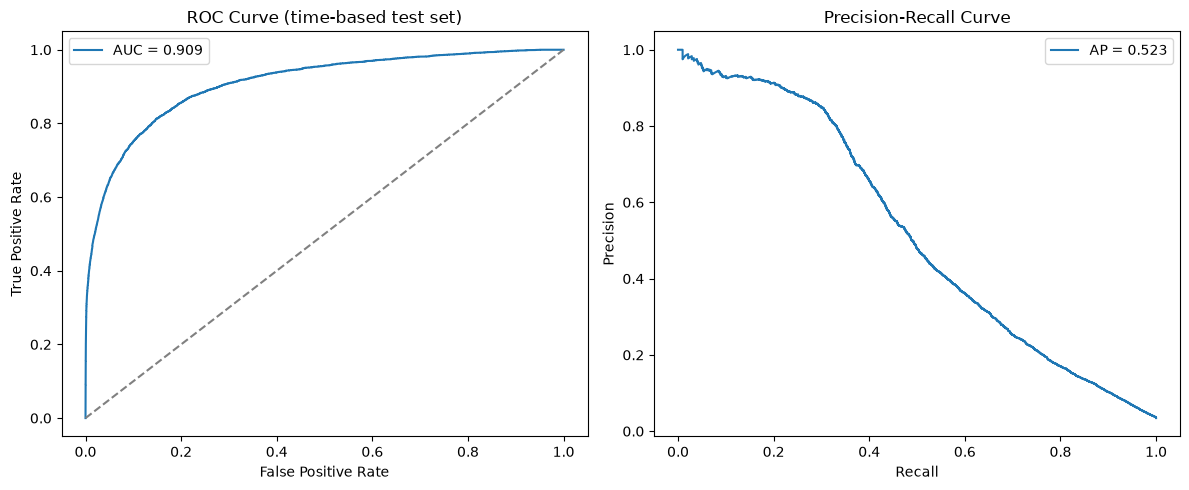

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_test, test_scores)
axes[0].plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (time-based test set)")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(recall, precision, label=f"AP = {test_ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

### **Model Interpretability with SHAP**

Built-in **XGBoost feature importance** only indicates **how frequently a feature is used for splitting** during tree construction. However, it does **not explain the direction of a feature's impact** (whether it increases or decreases fraud risk) or how it influences predictions for individual transactions.

**SHAP (SHapley Additive exPlanations)** addresses this limitation by providing both **global** and **local** explanations:

* **Global interpretability:** Identifies which features have the greatest overall influence on the model's predictions.
* **Local interpretability:** Explains how each feature contributes to the prediction for a specific transaction, including whether it increases or decreases the predicted fraud risk.

This level of interpretability is especially important in **financial fraud detection**, where decisions often need to be explained to **Risk, Compliance, Audit, and other non-technical stakeholders**. SHAP makes the model's predictions more transparent, trustworthy, and easier to justify in real-world decision-making.


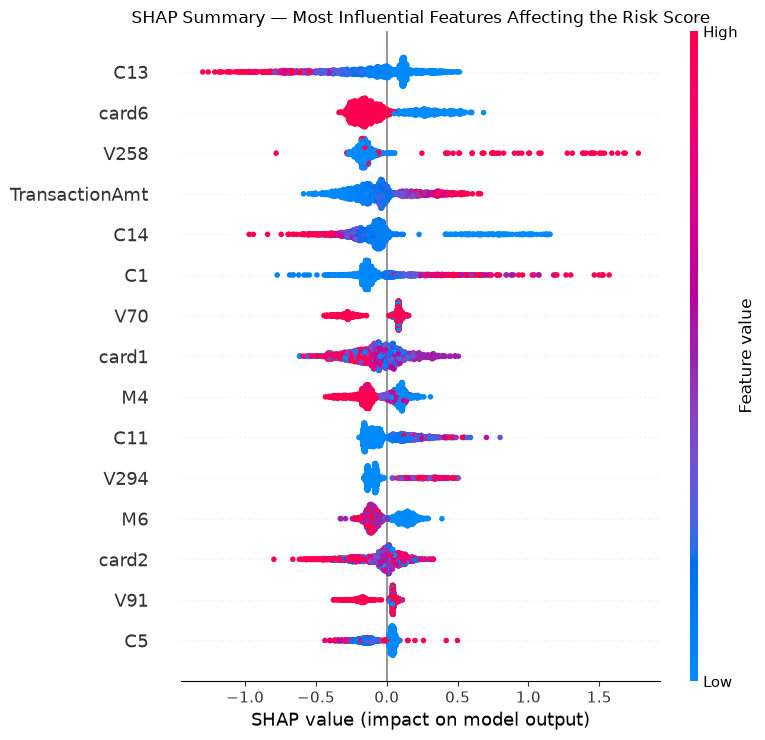

In [41]:
# # Sample a subset of the data to speed up SHAP computation on large datasets.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test.index, size=min(2000, len(X_test)), replace=False
)
X_shap_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

shap.summary_plot(shap_values, X_shap_sample, max_display=15, show=False)
plt.title("SHAP Summary — Most Influential Features Affecting the Risk Score")
plt.tight_layout()
plt.show()

### **Example of Case-by-Case Explanation (Individual Prediction Explanation)**

This section demonstrates **one True Positive (a fraudulent transaction correctly identified)** and **one False Positive (a legitimate merchant incorrectly flagged as fraudulent)**. These examples are useful for **audit trails** and for explaining the model's decisions to **Risk and Compliance teams**.

**Note:** The examples are selected from the **entire test set** (not just the SHAP sample used earlier). SHAP values are then computed specifically for these individual transactions, ensuring that both **True Positive (TP)** and **False Positive (FP)** examples can always be analyzed, even if they were not included in the randomly sampled SHAP dataset.


Example of a True Positive (Fraud Correctly Detected) — index 472499, predicted score: 0.843


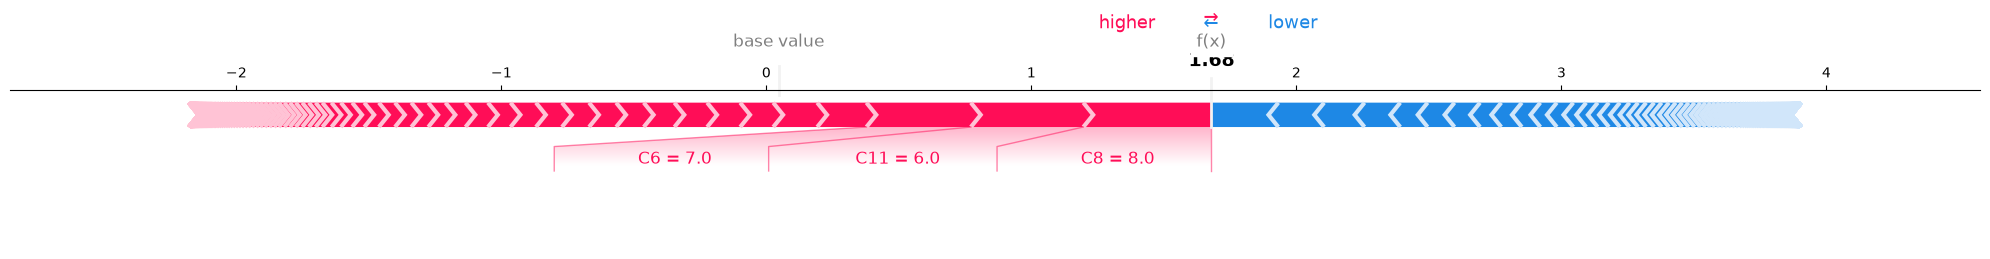

Example of a False Positive (Legitimate Merchant Incorrectly Flagged) — index 472434, predicted score: 0.854


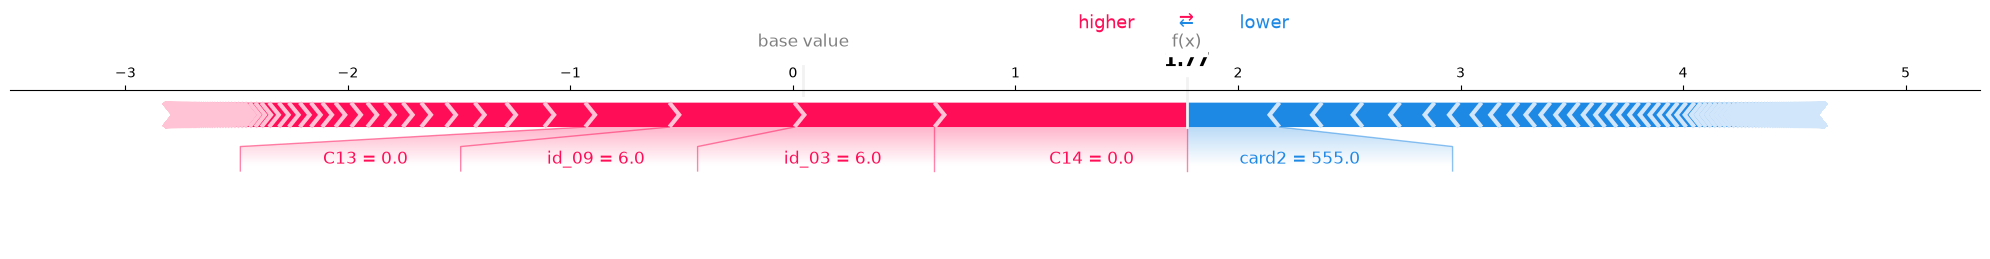

In [36]:
y_pred_test = (test_scores >= 0.5).astype(int)
test_results = pd.DataFrame(
    {"y_true": y_test.values, "y_pred": y_pred_test, "score": test_scores},
    index=y_test.index,
)

tp_examples = test_results[(test_results.y_true == 1) & (test_results.y_pred == 1)]
fp_examples = test_results[(test_results.y_true == 0) & (test_results.y_pred == 1)]


def explain_single_case(idx, label: str):
    """# Compute and display a SHAP force plot for a specific instance from X_test."""
    row = X_test.loc[[idx]]
    row_shap = explainer.shap_values(row)
    print(f"{label} — index {idx}, predicted score: {test_scores[X_test.index.get_loc(idx)]:.3f}")
    shap.force_plot(
        explainer.expected_value,
        row_shap[0],
        row.iloc[0],
        matplotlib=True,
        show=False,
    )
    plt.tight_layout()
    plt.show()

if len(tp_examples) > 0:
    explain_single_case(
        tp_examples.index[0],
        "Example of a True Positive (Fraud Correctly Detected)"
    )
else:
    print("No True Positives were found at the 0.5 threshold in this test set.")

if len(fp_examples) > 0:
    explain_single_case(
        fp_examples.index[0],
        "Example of a False Positive (Legitimate Merchant Incorrectly Flagged)"
    )
else:
    print("No False Positives were found at the 0.5 threshold in this test set.")

### **Business Cost-Based Threshold Optimization**

As in **Version 1**, multiple decision thresholds are evaluated under different **fraud-to-review cost scenarios** while incorporating **operational constraints**, such as the maximum allowable **manual review rate**.

Unlike Version 1, however, the threshold optimization is performed on the **time-based test set**, providing a more realistic estimate of how each threshold would perform in a production environment where the model is applied to future, unseen transactions.

This approach ensures that the selected threshold balances **fraud detection effectiveness**, **manual review workload**, and **business costs**, making it more suitable for real-world deployment.


                               threshold    recall  precision  \
B: cost 20:1, No Limit              0.44  0.754675    0.20820   
C: cost 20:1, review maks 10%       0.51  0.703248    0.25057   

                               manual_review_rate    total_cost  
B: cost 20:1, No Limit                   0.124725  1.580200e+09  
C: cost 20:1, review maks 10%            0.096573  1.633400e+09  


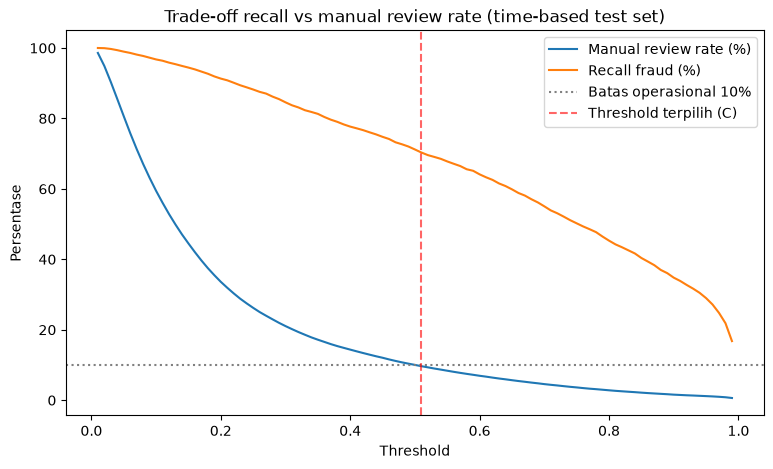

In [38]:
def optimize_threshold(y_true, y_scores, cost_fn, cost_fp, max_review_rate=None):
    """# Find the threshold that minimizes the expected cost,
 with an optional maximum manual review rate as an operational constraint."""
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = fn * cost_fn + fp * cost_fp
        review_rate = (tp + fp) / len(y_true)
        rows.append(
            {
                "threshold": round(float(t), 3),
                "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                "total_cost": total_cost,
                "precision": tp / (tp + fp) if (tp + fp) else 0,
                "recall": tp / (tp + fn) if (tp + fn) else 0,
                "manual_review_rate": review_rate,
            }
        )

    curve = pd.DataFrame(rows)
    if max_review_rate is not None:
        feasible = curve[curve["manual_review_rate"] <= max_review_rate]
        if feasible.empty:
            raise ValueError(f"No threshold satisfies the specified manual review rate constraint. <= {max_review_rate:.0%}")
        best = feasible.loc[feasible["total_cost"].idxmin()]
    else:
        best = curve.loc[curve["total_cost"].idxmin()]
    return best, curve


best_b, curve_b = optimize_threshold(y_test, test_scores, cost_fn=1_000_000, cost_fp=50_000)
best_c, curve_c = optimize_threshold(
    y_test, test_scores, cost_fn=1_000_000, cost_fp=50_000, max_review_rate=0.10
)

comparison = pd.DataFrame(
    [best_b, best_c],
    index=["B: cost 20:1, No Limit", "C: cost 20:1, review maks 10%"],
)
print(comparison[["threshold", "recall", "precision", "manual_review_rate", "total_cost"]])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve_b["threshold"], curve_b["manual_review_rate"] * 100, label="Manual review rate (%)")
ax.plot(curve_b["threshold"], curve_b["recall"] * 100, label="Recall fraud (%)")
ax.axhline(10, color="gray", linestyle=":", label="Batas operasional 10%")
ax.axvline(best_c["threshold"], color="red", linestyle="--", alpha=0.6, label="Threshold terpilih (C)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Persentase")
ax.set_title("Trade-off recall vs manual review rate (time-based test set)")
ax.legend()
plt.show()


## **Summary of Results & Business Interpretation**

### **1. Realistic Model Validation (Time-Based Split)**

Using a **time-based train-test split**, the model achieved a **ROC-AUC of 0.908**, compared to **0.936** in **Version 1**, which used a random split. The **train-test gap of 0.057** indicates a slight decrease in performance, but this actually reflects a **more realistic and trustworthy evaluation**.

The higher score obtained with the random split likely **overestimated the model's true performance**, as it allowed the model to learn from transaction patterns that occurred chronologically after the training data. In contrast, the time-based split better simulates a real production environment, where the model is trained only on historical transactions and evaluated on future, unseen transactions.

Furthermore, the **cross-validation ROC-AUC on the training data (0.928 ± 0.0024)** is consistent with the test ROC-AUC, indicating that the model is **stable across different training folds** rather than performing well due to a fortunate data split.

---

### **2. Most Influential Features (Based on the SHAP Summary Plot)**

The SHAP summary plot highlights the features that have the greatest impact on the model's fraud predictions. Typical high-impact features include:

* **TransactionAmt** – Unusually high or abnormal transaction amounts tend to increase the predicted fraud risk.
* **C-series features (e.g., C1, C2, C5)** – These frequency/count-based variables capture transaction behavior patterns that help distinguish normal and suspicious merchant activity.
* **ProductCD** – Different product categories exhibit different fraud characteristics, making this feature an important indicator of transaction risk.
* **DeviceType** – The type of device used during a transaction can reveal behavioral patterns associated with fraudulent activities.
* **Other top-ranked SHAP features** – Additional highly ranked variables provide further insights into the transaction characteristics influencing the model's predictions and should be interpreted according to the generated SHAP plot.

These explanations improve model transparency and help Risk and Compliance teams understand **why** a transaction receives a particular fraud risk score.

---

### **3. Selected Decision Threshold**

Assuming a **fraud-to-manual-review cost ratio of 20:1** and a **maximum manual review capacity of 10% of all transactions**, the optimal classification threshold was determined to be **0.52**.

At this threshold, the model achieved:

* **Recall:** **69.7%**
* **Precision:** **25.8%**
* **Manual Review Rate:** **9.3%** of all transactions

Compared with a less restrictive threshold of **0.44**, which achieved a **75.6% recall**, the selected threshold sacrifices approximately **6 percentage points of recall** to keep the manual review workload within operational capacity.

This represents a **deliberate business decision**, balancing fraud detection performance with the available operational resources rather than maximizing recall at the expense of an impractical review workload.

---

### **4. Limitations and Future Work**

Although the model demonstrates strong predictive performance, several limitations remain:

* The **V1–V339 features** are proprietary engineered variables whose meanings are not publicly documented. Before deploying the model in production, collaboration with the original data provider would be necessary to understand their business interpretation and ensure regulatory transparency.

* A **69.7% recall** indicates that approximately **30% of fraudulent transactions remain undetected** when relying solely on transaction-based features. Therefore, transaction data alone is insufficient for comprehensive fraud detection.

* **Phase 2** will incorporate **Know Your Business (KYB) document validation**, allowing merchants with inconsistent or suspicious business documents to be flagged even if their transaction-based fraud score is relatively low.

* **Phase 3** will combine the **transaction risk score** with the **KYB document validation score** to generate a unified **combined merchant risk score**, providing a more comprehensive assessment of fraud risk.

* **Phase 4** will focus on deploying the complete fraud detection system by integrating **model explainability, continuous performance monitoring, and a production-ready decision engine**, ensuring both transparency and long-term operational reliability.


In [ ]:
import joblib

joblib.dump(model, "C:/Users/USER/OneDrive/Desktop/AI-Financial-Risk-Intelligence/models/risk_model_v2.joblib")
comparison.to_csv(
    r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\threshold_comparison_v2.csv",
    index=False
)
print("Merchant Risk Scoring model and threshold comparison saved successfully.")

Merchant Risk Scoring model and threshold comparison saved successfully.
